In [1]:
!pip install scikit-fuzzy scipy numpy packaging networkx matplotlib
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 19.5 MB/s eta 0:00:00


In [10]:
suhu = ctrl.Antecedent(np.arange(0, 40, 1), 'suhu')
kelembapan = ctrl.Antecedent(np.arange(0, 100, 1), 'kelembapan')
kipas = ctrl.Consequent(np.arange(0, 100, 1), 'kipas')

suhu['rendah'] = fuzz.trimf(suhu.universe, [0, 0, 15])
suhu['sedang'] = fuzz.trimf(suhu.universe, [10, 20, 30])
suhu['tinggi'] = fuzz.trimf(suhu.universe, [25, 40, 40])

kelembapan['rendah'] = fuzz.trimf(kelembapan.universe, [0, 0, 40])
kelembapan['sedang'] = fuzz.trimf(kelembapan.universe, [30, 50, 70])
kelembapan['tinggi'] = fuzz.trimf(kelembapan.universe, [60, 100, 100])

kipas['rendah'] = fuzz.trimf(kipas.universe, [0, 0, 40])
kipas['sedang'] = fuzz.trimf(kipas.universe, [30, 50, 70])
kipas['tinggi'] = fuzz.trimf(kipas.universe, [60, 100, 100])

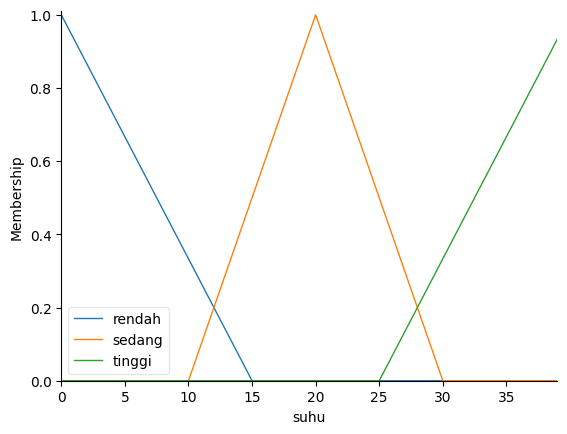

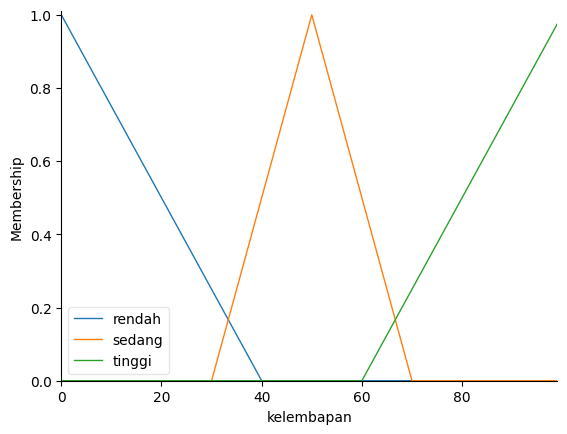

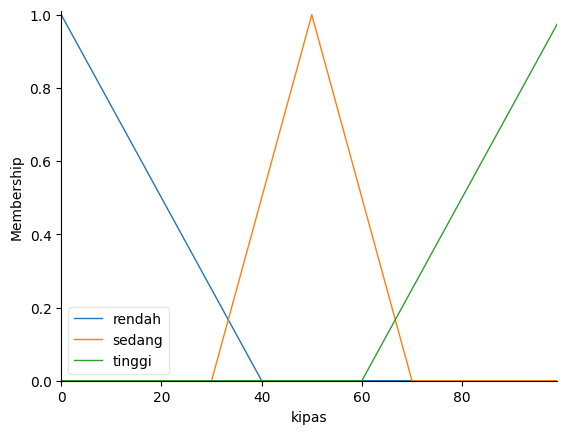

In [13]:
suhu.view()
kelembapan.view()
kipas.view()

80.80071355759424


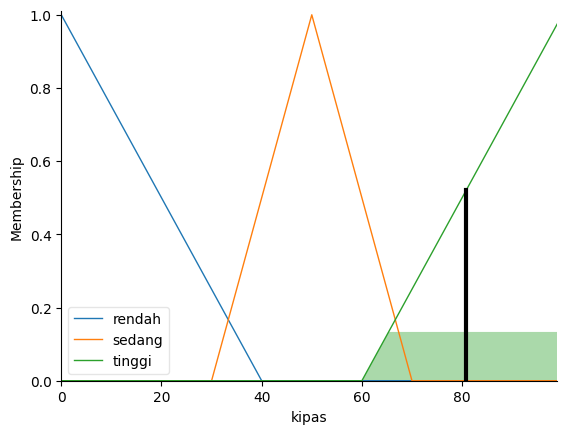

In [14]:
mesin = ctrl.ControlSystem([
    ctrl.Rule(suhu['rendah'] & kelembapan['rendah'], kipas['rendah']),
    ctrl.Rule(suhu['sedang'] & kelembapan['rendah'], kipas['sedang']),
    ctrl.Rule(suhu['tinggi'] & kelembapan['sedang'], kipas['tinggi'])
])

sistem = ctrl.ControlSystemSimulation(mesin)
sistem.input['suhu'] = 27
sistem.input['kelembapan'] = 50
sistem.compute()
print(sistem.output['kipas'])
kipas.view(sim=sistem)